## UCS619 Quantum Computing: Lab Assignment-9
##  Quantum Crptography and Quantum Search

Name: Smarth Kaushal | Roll No. 102497023 | Group: 3Q21 | Lab Instructor: Dr. Samya Muhuri

### Experiment 1: Quantum Key Distribution


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("All imports successful!")

All imports successful!


In [2]:
# Step 1: Alice generates a random bit string and random basis choices
num_qubits = 16   # number of qubits to send

alice_bits   = [random.randint(0, 1) for _ in range(num_qubits)]
alice_bases  = [random.randint(0, 1) for _ in range(num_qubits)]  # 0 = Z-basis, 1 = X-basis

print("Alice's bits  :", alice_bits)
print("Alice's bases :", alice_bases, "  (0=Z, 1=X)")

Alice's bits  : [0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1]
Alice's bases : [0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1]   (0=Z, 1=X)


In [5]:
def encode_qubits(bits, bases):
    """Alice encodes her classical bits into qubits using her chosen bases.

    - If basis = 0 (Z): |0⟩ encodes bit 0, |1⟩ encodes bit 1
    - If basis = 1 (X): |+⟩ encodes bit 0, |−⟩ encodes bit 1
    """
    circuits = []
    for bit, basis in zip(bits, bases):
        qc = QuantumCircuit(1, 1)

        # Prepare the qubit in the correct state
        if bit == 1:
            qc.x(0)          # flip to |1⟩
        if basis == 1:
            qc.h(0)          # apply Hadamard to switch to X-basis

        circuits.append(qc)
    return circuits

encoded_qubits = encode_qubits(alice_bits, alice_bases)
print(f"Alice has encoded {len(encoded_qubits)} qubits.")

Alice has encoded 16 qubits.


In [6]:
# Step 2: Bob randomly chooses measurement bases
bob_bases = [random.randint(0, 1) for _ in range(num_qubits)]
print("Bob's bases:", bob_bases, "  (0=Z, 1=X)")

Bob's bases: [0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0]   (0=Z, 1=X)


In [7]:
def measure_qubits(circuits, bases):
    """Bob measures each qubit using his chosen basis."""
    simulator = AerSimulator()
    results = []

    for qc, basis in zip(circuits, bases):
        # Make a copy so we don't modify Alice's original circuit
        measure_circ = qc.copy()

        if basis == 1:
            measure_circ.h(0)   # switch to X-basis before measuring

        measure_circ.measure(0, 0)

        job    = simulator.run(measure_circ, shots=1)
        counts = job.result().get_counts()

        # Extract the single measurement result
        bit = int(list(counts.keys())[0])
        results.append(bit)

    return results

bob_results = measure_qubits(encoded_qubits, bob_bases)
print("Bob's measured bits:", bob_results)

Bob's measured bits: [0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1]


Simulation failed and returned the following error message:
ERROR:  [Experiment 0] Insufficient memory to run circuit circuit-111 using the statevector simulator. Required memory: 65536M, max memory: 16024M


In [8]:
# Step 3: Basis reconciliation — keep only the bits where bases match
def sift_key(alice_bits, alice_bases, bob_results, bob_bases):
    """Compare bases publicly and keep matching positions."""
    alice_key = []
    bob_key   = []

    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]:   # bases match!
            alice_key.append(alice_bits[i])
            bob_key.append(bob_results[i])

    return alice_key, bob_key

alice_key, bob_key = sift_key(alice_bits, alice_bases, bob_results, bob_bases)

print(f"Total qubits sent : {num_qubits}")
print(f"Matching bases    : {len(alice_key)}")
print(f"Alice's key       : {alice_key}")
print(f"Bob's key         : {bob_key}")
print(f"Keys match        : {alice_key == bob_key}")

Total qubits sent : 16
Matching bases    : 9
Alice's key       : [0, 0, 0, 0, 1, 1, 1, 1, 0]
Bob's key         : [0, 0, 0, 0, 1, 1, 1, 1, 0]
Keys match        : True


In [9]:
# Step 4: Error checking — in a real scenario we sacrifice a few bits tocheck for eavesdropping. Here we just compute the error rate.

errors = sum(a != b for a, b in zip(alice_key, bob_key))
error_rate = errors / len(alice_key) if alice_key else 0

print(f"Number of errors : {errors} / {len(alice_key)}")
print(f"Error rate       : {error_rate:.2%}")

if error_rate == 0:
    print("\n✅ No errors detected — channel appears secure!")
else:
    print("\n⚠️  Errors detected — possible eavesdropping or noise!")

Number of errors : 0 / 9
Error rate       : 0.00%

✅ No errors detected — channel appears secure!


### QKD with Eavesdropper (Eve)

Now let's simulate what happens when Eve intercepts and re-sends the qubits. Eve has to guess the basis, and any wrong guess will introduce errors that Alice and Bob can detect.

In [10]:
def eve_intercept(circuits):
    """Eve intercepts each qubit, measures in a random basis, and re-encodes."""
    simulator  = AerSimulator()
    new_circs  = []
    eve_bases  = [random.randint(0, 1) for _ in circuits]

    for qc, basis in zip(circuits, eve_bases):
        # Eve measures
        intercept = qc.copy()
        if basis == 1:
            intercept.h(0)
        intercept.measure(0, 0)

        job    = simulator.run(intercept, shots=1)
        counts = job.result().get_counts()
        bit    = int(list(counts.keys())[0])

        # Eve re-encodes what she measured and forwards to Bob
        new_qc = QuantumCircuit(1, 1)
        if bit == 1:
            new_qc.x(0)
        if basis == 1:
            new_qc.h(0)

        new_circs.append(new_qc)

    return new_circs

# Run QKD with Eve intercepting
intercepted_qubits   = eve_intercept(encoded_qubits)
bob_results_with_eve = measure_qubits(intercepted_qubits, bob_bases)

alice_key_e, bob_key_e = sift_key(alice_bits, alice_bases, bob_results_with_eve, bob_bases)

errors_e    = sum(a != b for a, b in zip(alice_key_e, bob_key_e))
error_rate_e = errors_e / len(alice_key_e) if alice_key_e else 0

print("=== With Eve Eavesdropping ===")
print(f"Matching bits : {len(alice_key_e)}")
print(f"Errors        : {errors_e}")
print(f"Error rate    : {error_rate_e:.2%}")

if error_rate_e > 0.1:
    print("\n High error rate — Eve's presence is detectable!")
else:
    print("\n Eve got lucky this time (low error rate by chance).")

=== With Eve Eavesdropping ===
Matching bits : 9
Errors        : 4
Error rate    : 44.44%

 High error rate — Eve's presence is detectable!


### Experiment 2: BB84

In [17]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np

num_qubits = 20

alice_basis = np.random.randint(2, size=num_qubits)
alice_state = np.random.randint(2, size=num_qubits)
bob_basis   = np.random.randint(2, size=num_qubits)

print("Alice state:", alice_state)
print("Alice basis:", alice_basis)
print("Bob basis:", bob_basis)

Alice state: [0 0 1 1 1 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0]
Alice basis: [1 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 0]
Bob basis: [1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1]


In [18]:
def bb84_circuit(state, basis, measurement_basis):
    
    n = len(state)
    qc = QuantumCircuit(n, n)

    # Alice encoding
    for i in range(n):
        if state[i] == 1:
            qc.x(i)
        if basis[i] == 1:
            qc.h(i)

    # Bob measurement basis choice
    for i in range(n):
        if measurement_basis[i] == 1:
            qc.h(i)

    qc.measure(range(n), range(n))
    return qc

In [19]:
# Run simulation
qc = bb84_circuit(alice_state, alice_basis, bob_basis)

sim = AerSimulator(method="statevector")

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# most likely outcome
measured = max(counts, key=counts.get)[::-1]  # reverse bit order

In [20]:
# Key generation
encryption_key = ""

for i in range(num_qubits):
    if alice_basis[i] == bob_basis[i]:
        encryption_key += measured[i]

print("\nFinal BB84 Key:", encryption_key)


Final BB84 Key: 01100100


### Experiment 3: Grover’s Search

In [21]:
def grover_oracle(target, n_qubits):
    """Build the oracle circuit that flips the phase of the target state.

    It converts the target state to |11...1⟩, applies a multi-controlled Z,
    then undoes the conversion.
    """
    oracle = QuantumCircuit(n_qubits, name='Oracle')

    # Flip qubits that are '0' in the target binary string
    for i, bit in enumerate(reversed(target)):   # LSB first
        if bit == '0':
            oracle.x(i)

    # Multi-controlled Z (phase flip on |11...1⟩)
    oracle.h(n_qubits - 1)
    oracle.mcx(list(range(n_qubits - 1)), n_qubits - 1)   # Toffoli generalised
    oracle.h(n_qubits - 1)

    # Undo the bit flips
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    return oracle


def grover_diffuser(n_qubits):
    """The diffusion operator (inversion about the mean)."""
    diffuser = QuantumCircuit(n_qubits, name='Diffuser')

    diffuser.h(range(n_qubits))
    diffuser.x(range(n_qubits))
    diffuser.h(n_qubits - 1)
    diffuser.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    diffuser.h(n_qubits - 1)
    diffuser.x(range(n_qubits))
    diffuser.h(range(n_qubits))

    return diffuser

print("Grover oracle and diffuser functions defined.")

Grover oracle and diffuser functions defined.


In [24]:
def run_grover(target_state, n_qubits, shots=1024):
    """Build and run the full Grover's algorithm circuit."""

    N          = 2 ** n_qubits
    iterations = max(1, int(np.pi / 4 * np.sqrt(N)))  # optimal number of iterations

    print(f"Search space   : {N} states  ({n_qubits} qubits)")
    print(f"Target state   : |{target_state}⟩  (decimal {int(target_state, 2)})")
    print(f"Iterations     : {iterations}")

    # Build the circuit
    qc = QuantumCircuit(n_qubits, n_qubits)

    # Step 1: Initialise all qubits in superposition
    qc.h(range(n_qubits))
    qc.barrier()

    # Build oracle and diffuser as gate objects
    oracle   = grover_oracle(target_state, n_qubits)
    diffuser = grover_diffuser(n_qubits)

    # Steps 2 & 3: Apply Grover iteration
    for i in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
        qc.barrier()

    # Step 4: Measure
    qc.measure(range(n_qubits), range(n_qubits))

    # Simulate
    simulator = AerSimulator()
    job       = simulator.run(qc, shots=shots)
    counts    = job.result().get_counts()

    return qc, counts, iterations

print("run_grover function defined.")

run_grover function defined.


In [25]:
# Run Grover's on a 3-qubit system (8 possible states)
# We'll search for the state |101⟩

n = 3
target  = '101'   # can be any binary string of length n

grover_qc, counts, iters = run_grover(target, n, shots=1024)

Search space   : 8 states  (3 qubits)
Target state   : |101⟩  (decimal 5)
Iterations     : 2


Grover's Circuit:


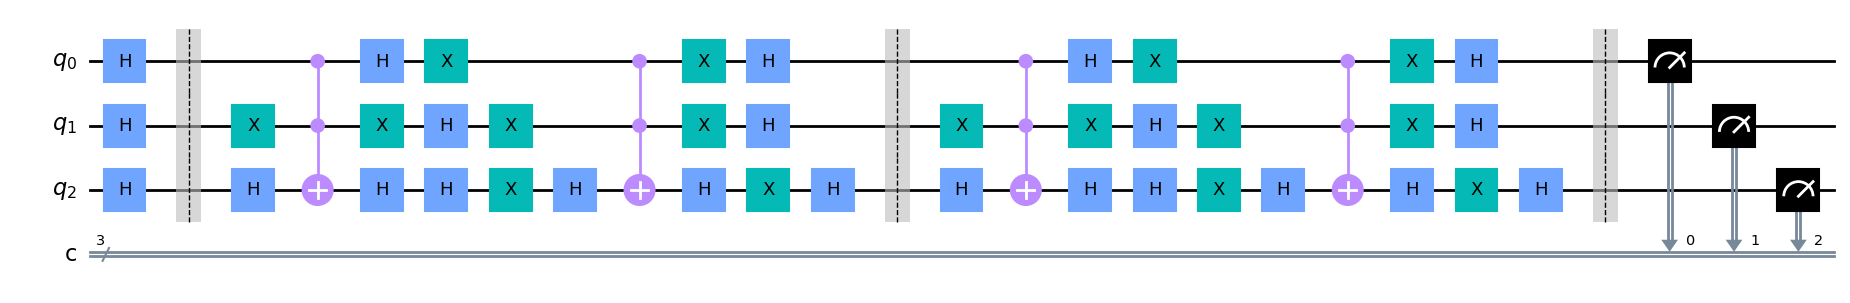

In [26]:
# Show the circuit
print("Grover's Circuit:")
display(grover_qc.draw('mpl', style='clifford',fold=-1))